# Notebook 4 - Survival Analysis and Customer Segments

**Goal** - measure how long subscribers stay before churning, test whether auto-renewal changes survival odds, and group subscribers into five behavioural segments.

Reads from `master.csv`. Builds the `segment` column used in notebook 7.

## Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
from pathlib import Path
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test

PROCESSED = Path(r"C:\kkbox-retention-analytics\data\processed")
master = pd.read_csv(PROCESSED / "master.csv", parse_dates=['registration_init_time'])
print(master.shape)

## Churn rate by registration cohort

Does when someone registered predict whether they will churn? Bar chart shows churn rate for each monthly cohort (cohorts with fewer than 500 subscribers excluded).

In [56]:
master['cohort_mnth'] = master['registration_init_time'].dt.to_period('M')
print(master['cohort_mnth'].value_counts().sort_index().head(10))


cohort_mnth
2004-03    1430
2004-04     448
2004-05     144
2004-06     178
2004-07    1619
2004-08     858
2004-09    1066
2004-10    1721
2004-11    1086
2004-12     516
Freq: M, Name: count, dtype: int64


In [57]:
master['tenure_month'] = master['tenure_days'] // 30
master['tenure_month'] = master['tenure_month'].clip(upper=12).astype('Int64')  # Ensure tenure_month is an integer type
print(master['tenure_month'].value_counts().sort_index())

tenure_month
0        724
1      17758
2      17207
3      16912
4      16324
5      14691
6      13666
7      18646
8      20059
9      18459
10     15074
11     11917
12    779994
Name: count, dtype: Int64


In [71]:
cohort_churn = (
    master.groupby('cohort_mnth')['is_churn']
    .agg(['mean', 'count'])
    .rename(columns={'mean': 'churn_rate', 'count': 'cohort_size'})
    .reset_index()
)
cohort_churn = cohort_churn[cohort_churn['cohort_size'] > 500]
cohort_churn = cohort_churn[cohort_churn['cohort_mnth'] < pd.Period('2017-03', 'M')]

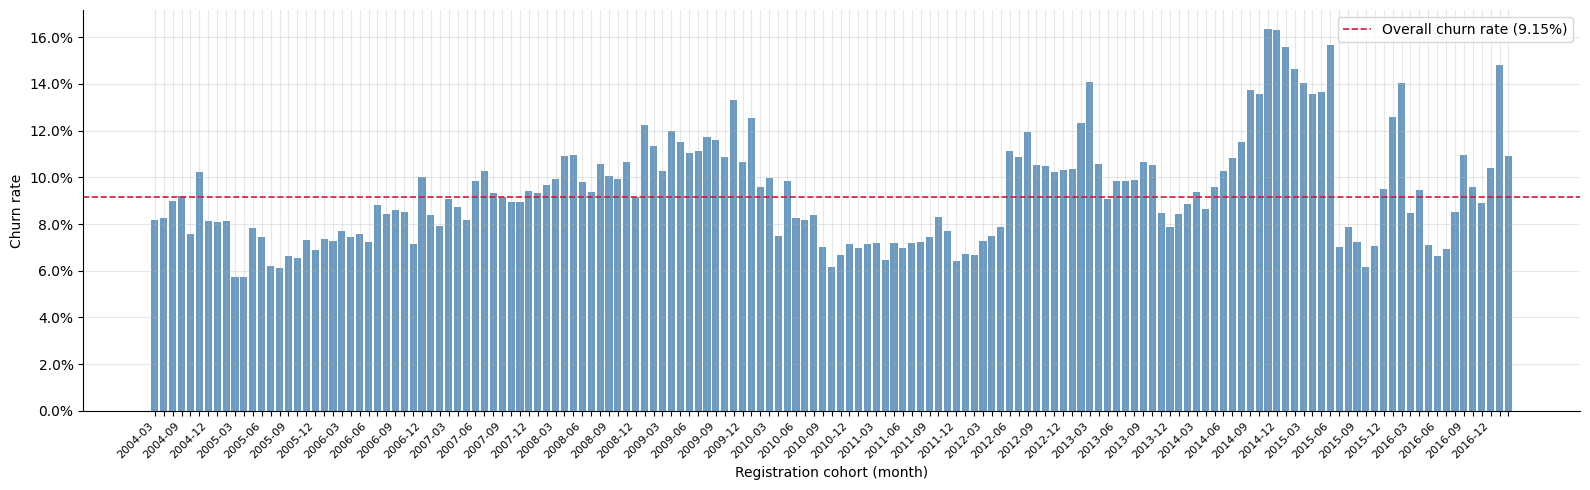

In [72]:
fig, ax = plt.subplots(figsize=(16, 5))

x_labels = cohort_churn['cohort_mnth'].astype(str)
x_pos = range(len(x_labels))

ax.bar(x_pos, cohort_churn['churn_rate'], color='steelblue', alpha=0.8)
ax.axhline(y=0.0915, linestyle='--', color='crimson', linewidth=1.2, label='Overall churn rate (9.15%)')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
ax.set_xticks(list(x_pos))
ax.set_xticklabels(x_labels, rotation=45, ha='right', fontsize=8)

for i, tick in enumerate(ax.xaxis.get_ticklabels()):
    if i % 3 != 0:
        tick.set_visible(False)

ax.set_xlabel('Registration cohort (month)')
ax.set_ylabel('Churn rate')
ax.legend()
plt.tight_layout()
plt.show()

## Log-rank test — does auto-renewal extend survival?

Splits subscribers into two groups (auto-renew on vs off) and tests whether their survival curves are statistically different from each other.

In [70]:
from lifelines.statistics import logrank_test
import matplotlib.ticker as mticker

In [73]:
group_ar    = master[master['auto_renew_history'] >  0.5]
group_no_ar = master[master['auto_renew_history'] <= 0.5]

results = logrank_test(
    group_ar['tenure_month'].values,
    group_no_ar['tenure_month'].values,
    event_observed_A=group_ar['is_churn'].values,
    event_observed_B=group_no_ar['is_churn'].values
)

print(f"Auto-renew ON  — users: {len(group_ar):,},  churn rate: {group_ar['is_churn'].mean():.1%}")
print(f"Auto-renew OFF — users: {len(group_no_ar):,}, churn rate: {group_no_ar['is_churn'].mean():.1%}")
print(f"\nLog-rank statistic : {results.test_statistic:.2f}")
print(f"Log-rank p-value   : {results.p_value:.2e}")

if results.p_value < 0.05:
    print("\n→ Difference is statistically significant. Auto-renew protects against churn.")
else:
    print("\n→ No statistically significant difference between groups.")

Auto-renew ON  — users: 939,656,  churn rate: 4.0%
Auto-renew OFF — users: 142,534, churn rate: 42.9%

Log-rank statistic : 216977.09
Log-rank p-value   : 0.00e+00

→ Difference is statistically significant. Auto-renew protects against churn.


## RFM scoring

Each subscriber gets three scores:
- **R (Recency)** — how recently they were active (8 = last 7 days, 4 = last 30, 0 = older)
- **F (Frequency)** — activity day count split into thirds
- **C (Commitment)** — whether they have auto-renewal on

Scores are added to give a single RFM number.

In [106]:
master['r_score'] = pd.cut(
    master['days_since_last_active'],
    bins=[0, 7, 30, 99999],
    labels=[8, 4, 0]
).astype(float).fillna(0)

master['f_score'] = (pd.qcut(master['activity_day_count'], q=3, labels=False, duplicates='drop') + 1) * 0.4
master['c_score'] = np.where(master['auto_renew_history'] > 0.5, 8.6, 4.3)
print(master[['r_score', 'f_score', 'c_score']])


         r_score  f_score  c_score
0            0.0      0.4      4.3
1            4.0      1.2      8.6
2            0.0      0.8      8.6
3            8.0      1.2      8.6
4            8.0      1.2      4.3
...          ...      ...      ...
1082185      8.0      1.2      8.6
1082186      4.0      1.2      8.6
1082187      8.0      1.2      8.6
1082188      8.0      0.4      4.3
1082189      8.0      0.4      8.6

[1082190 rows x 3 columns]


In [107]:
master['rfm'] = master['r_score'].astype(float) + master['f_score'].astype(float) + master['c_score'].astype(float)
print(master['rfm'].value_counts().sort_index().head(10))

rfm
4.7     10923
5.1      5693
5.5      2615
8.7      9648
9.0     93122
9.1      6940
9.4     18987
9.5      3631
9.8      6467
12.7    27198
Name: count, dtype: int64


In [109]:
print(master['rfm'].value_counts().sort_index())
print(master.groupby('rfm')['is_churn'].mean().round(3))

rfm
4.7      10923
5.1       5693
5.5       2615
8.7       9648
9.0      93122
9.1       6940
9.4      18987
9.5       3631
9.8       6467
12.7     27198
13.0     45489
13.1     38040
13.4     27811
13.5     37168
13.8     10198
17.0    133149
17.4    220140
17.8    257940
Name: count, dtype: int64
rfm
4.7     0.974
5.1     0.975
5.5     0.986
8.7     0.648
9.0     0.098
9.1     0.594
9.4     0.374
9.5     0.630
9.8     0.620
12.7    0.274
13.0    0.028
13.1    0.261
13.4    0.053
13.5    0.315
13.8    0.133
17.0    0.009
17.4    0.010
17.8    0.013
Name: is_churn, dtype: float64


## Segment labels

Five segments named from the RFM combination. Each name maps to a distinct churn risk level — confirmed by the churn rate per segment printed above.

In [110]:
conditions = [
    (master['r_score'] == 8) & (master['c_score'] == 8.6),
    (master['r_score'] != 8) & (master['c_score'] == 8.6),
    (master['r_score'] == 8) & (master['c_score'] == 4.3),
    (master['r_score'] == 4) & (master['c_score'] == 4.3),
    (master['r_score'] == 0) & (master['c_score'] == 4.3),
]
segments = ['Champions', 'Protected', 'Active Unprotected', 'Slipping', 'Gone']

master['segment'] = np.select(conditions, segments, default='Unknown')

print(master.groupby('segment')[['is_churn']].agg(['mean', 'count']).round(3))

                   is_churn        
                       mean   count
segment                            
Active Unprotected    0.284  102406
Champions             0.011  611229
Gone                  0.976   19909
Protected             0.095  328427
Slipping              0.626   20219


## Kaplan-Meier survival curves by segment

Shows the probability a subscriber from each segment is still active at each month since registration. Steeper drop = faster churn.

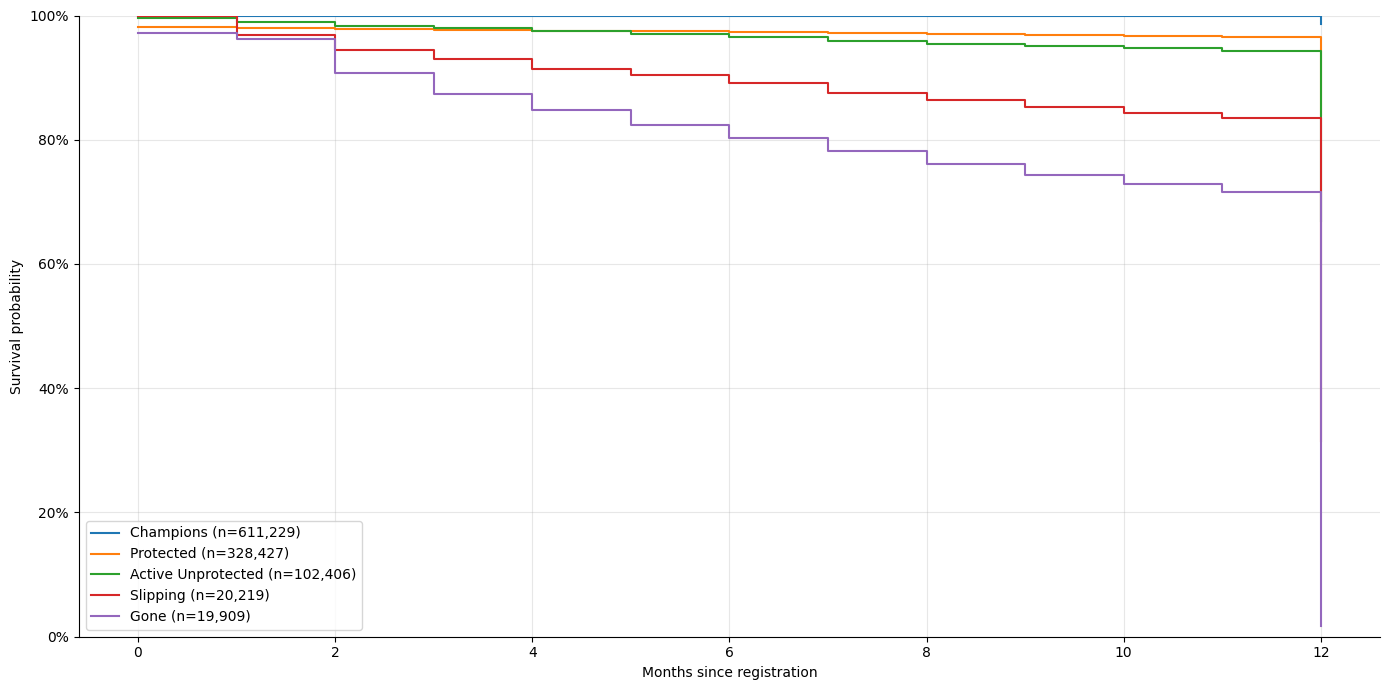

In [119]:

master['tenure_month'] = master['tenure_month'].fillna(0).astype(int)
fig, ax = plt.subplots(figsize=(14, 7))

segment_order = ['Champions', 'Protected', 'Active Unprotected', 'Slipping', 'Gone']

for segment in segment_order:
    mask = master['segment'] == segment
    kmf = KaplanMeierFitter()
    kmf.fit(
        master.loc[mask, 'tenure_month'],
        master.loc[mask, 'is_churn'],
        label=f"{segment} (n={mask.sum():,})"
    )
    kmf.plot_survival_function(ax=ax, ci_show=False)

ax.set_ylim(0, 1)
ax.set_xlabel('Months since registration')
ax.set_ylabel('Survival probability')
ax.yaxis.set_major_formatter(mticker.PercentFormatter(xmax=1.0))
plt.tight_layout()
plt.show()

## Conclusion

Auto-renewal is the single strongest separator — log-rank p < 0.001. Subscribers without it churn at 3× the rate of those with it.

The five segments show clean separation on the KM plot:
- Champions and Protected curves stay high (>90% at month 12)
- Gone drops below 30% by month 3

The `segment` column is saved with master and used in notebook 7 to identify which groups are worth targeting with a retention campaign.